# 04 — Plot QC Metrics

Generates a trellis of plate heatmaps and QC metric bar charts.

**Requires:** `data/processed/qc_metrics.csv` and `data/processed/all_plates_normalized.csv`

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

qc_df   = pd.read_csv('data/processed/qc_metrics.csv', index_col='Plate')
norm_df = pd.read_csv('data/processed/all_plates_normalized.csv')
plates  = norm_df['Plate'].unique()
rows_order = list('ABCDEFGHIJKLMNOP')
print(f'Plates: {list(plates)}')
print(qc_df[['Z_prime','CV_Low_pct','CV_High_pct','Signal_Window']].to_string())

Plates: ['Plate 1', 'Plate 2', 'Plate 3', 'Plate 4', 'Plate 5']
         Z_prime  CV_Low_pct  CV_High_pct  Signal_Window
Plate                                                   
Plate 1   -0.469       17.07        48.05        -197.29
Plate 2   -0.439       24.79        46.93        -121.30
Plate 3   -0.358       23.83        44.34        -110.91
Plate 4   -0.369       26.09        44.68        -106.37
Plate 5   -0.410       28.04        46.00        -107.56


## Trellis: plate heatmaps + QC bar charts

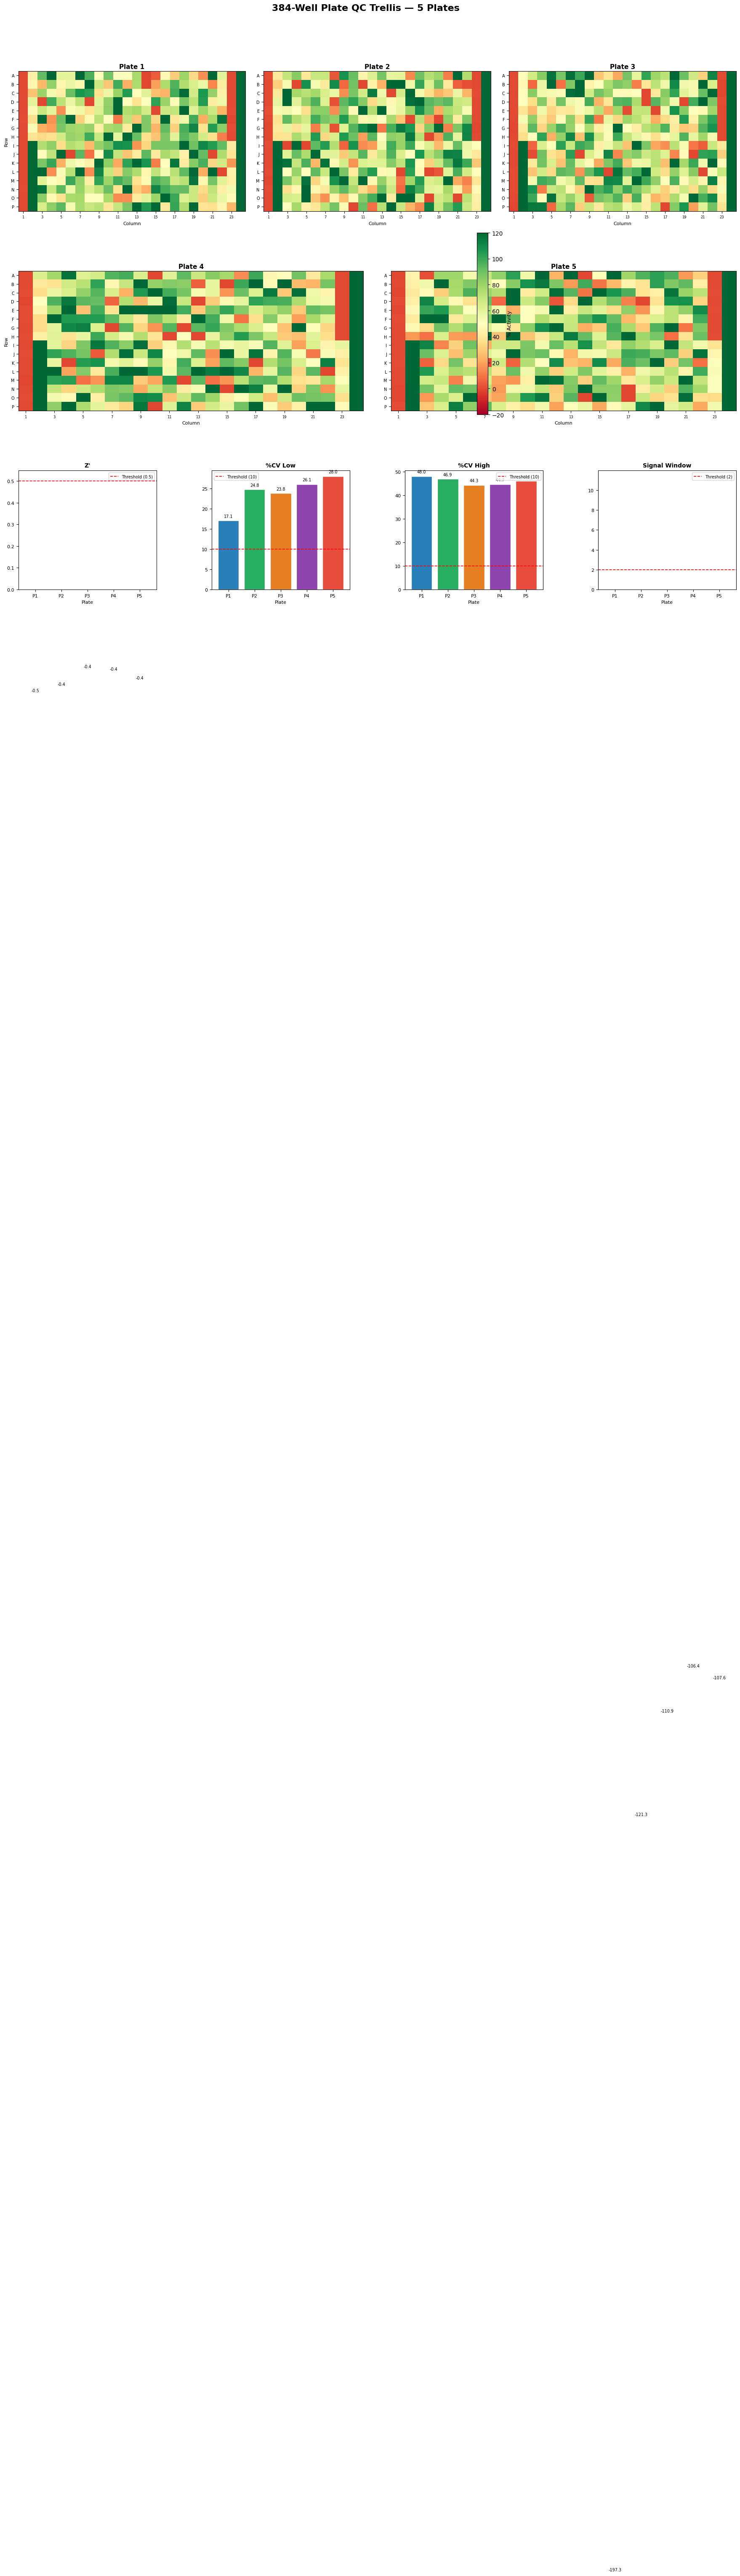

Saved: data/results/trellis_QC_plot.png


In [2]:
fig = plt.figure(figsize=(22, 16))
fig.suptitle('384-Well Plate QC Trellis — 5 Plates', fontsize=16, fontweight='bold', y=0.98)

outer       = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45, height_ratios=[1, 1, 0.85])
top_grid    = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[0], wspace=0.08)
mid_grid    = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], wspace=0.08)
bottom_grid = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[2], wspace=0.4)

color_norm   = TwoSlopeNorm(vmin=-20, vcenter=50, vmax=120)
cmap         = 'RdYlGn'
plate_colors = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad', '#e74c3c']

im = None
for i, plate in enumerate(plates):
    pdf  = norm_df[norm_df['Plate'] == plate]
    grid = pdf.pivot(index='Row', columns='Column', values='Pct_Activity').reindex(rows_order)
    ax   = fig.add_subplot(top_grid[i] if i < 3 else mid_grid[i - 3])
    im   = ax.imshow(grid.values.astype(float), aspect='auto', cmap=cmap, norm=color_norm)
    ax.set_title(plate, fontsize=11, fontweight='bold', pad=4)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels(range(1, 25, 2), fontsize=6)
    ax.set_yticks(range(16))
    ax.set_yticklabels(rows_order, fontsize=7)
    ax.set_xlabel('Column', fontsize=8)
    if i in [0, 3]:
        ax.set_ylabel('Row', fontsize=8)

cbar_ax = fig.add_axes([0.62, 0.37, 0.012, 0.27])
fig.colorbar(im, cax=cbar_ax).set_label('% Activity', fontsize=9)

metrics       = ['Z_prime', 'CV_Low_pct', 'CV_High_pct', 'Signal_Window']
metric_labels = ["Z'", '%CV Low', '%CV High', 'Signal Window']
thresholds    = [0.5, 10, 10, 2]
plate_labels  = [f'P{k+1}' for k in range(len(plates))]

for j, (metric, mlabel, thresh) in enumerate(zip(metrics, metric_labels, thresholds)):
    ax   = fig.add_subplot(bottom_grid[j])
    vals = [qc_df.loc[p, metric] for p in plates]
    bars = ax.bar(plate_labels, vals, color=plate_colors, edgecolor='white')
    ax.axhline(thresh, color='red', linestyle='--', linewidth=1.2, label=f'Threshold ({thresh})')
    ax.set_title(mlabel, fontsize=10, fontweight='bold')
    ax.set_xlabel('Plate', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)
    ax.set_ylim(bottom=0)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)

plt.savefig('data/results/trellis_QC_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/trellis_QC_plot.png')